In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
from hydrosense.database.meteo import CatalogueMeteo
from hydrosense.preprocess.meteo_fusion import SynthPrecipitation

In [3]:
import os
import requests
import pandas as pd
import warnings

In [ ]:
DATASET_ID = "6569b51ae64326786e4e8e1a"
API_URL = f"https://www.data.gouv.fr/api/1/datasets/{DATASET_ID}/"


In [6]:
reponse = requests.get(API_URL)
reponse.raise_for_status()

In [9]:
reponse.json()

{'access_audiences': [],
 'access_type': 'open',
 'access_type_reason': None,
 'access_type_reason_category': None,
 'acronym': None,
 'archived': None,
 'authorization_request_url': None,
 'badges': [{'kind': 'hvd'}],
 'contact_points': [],
 'created_at': '2023-12-01T10:27:38.839000+00:00',
 'deleted': None,
 'description': "### Présentation\n\nDonnées climatologiques de toutes les stations de métropole et d'outre-mer depuis leur ouverture, pour tous les paramètres disponibles. Ces données ont subi un contrôle climatologique.\n\n### Informations techniques\n\n- Les données quotidiennes sont proposées en téléchargement, par département, et par lots de période au format csv compressé\n- L'ensemble des paramètres est fourni pour l'ensemble des stations météorologiques\n- Les heures sont exprimées en UTC pour la métropole et en FU pour l'outre-mer\n- La mise à jour des fichiers est annuelle pour les historiques avant 1950, mensuelles pour les fichiers de 1950 jusqu'à l'année -2 et quotidi

In [15]:
list_url = [
    {'titre': res.get('title'), 'url': res.get('url')}
            for res in reponse.json().get('resources', [])
            if res.get('title', '').startswith('Q') and "RR-T-Vent" in res.get('title', '')
        ]

print(list_url[:10])

[{'titre': 'Q_descriptif_champs_RR-T-Vent.csv', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_descriptif_champs_RR-T-Vent.csv'}, {'titre': 'QUOT_departement_01_periode_avant-1949_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_01_avant-1949_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_01_periode_1950-2024_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_01_previous-1950-2024_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_01_periode_2025-2026_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_01_latest-2025-2026_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_02_periode_avant-1949_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/QUOT/Q_02_avant-1949_RR-T-Vent.csv.gz'}, {'titre': 'QUOT_departement_02_periode_1950-2024_RR-T-Vent', 'url': 'https://object.files.data.gouv.fr/met

In [18]:
'avant' in list_url[1]['titre']

True

### Import de précipitation sur le piezo

In [26]:
test_file = '/home/charourou/projects/Projet_Hydrosense/data/piezo_bourdet_clean.csv'
df_piezo = pd.read_csv(test_file, sep=';')

synthetiseur = SynthPrecipitation(df_piezo)
departement = '79'


In [27]:
resultat = synthetiseur.search(departement)
print(resultat)


🌍 Recherche des stations météo pour le département 79...
🔍 Analyse du fichier de référence : QUOT_departement_79_periode_2025-2026_RR-T-Vent
🎯 17 stations actives identifiées pour le 79.
📖 Récupération de l'historique : QUOT_departement_79_periode_1950-2024_RR-T-Vent.csv.gz
⚙️ Nettoyage et assemblage final pour 17 stations...
✅ Extraction départementale terminée !
🎯 Station météo retenue : 79220002 (à 3.70 km)
🎯 Station météo retenue : 79191005 (à 19.01 km)
🎯 Station météo retenue : 79320002 (à 27.24 km)
{'79220002': {'dataframe':      NUM_POSTE     date_RR     LAT       LON   RR    TM  FFM
0     79220002  2008-10-23  46.231 -0.668667  0.0   NaN  NaN
1     79220002  2008-10-24  46.231 -0.668667  0.0   NaN  NaN
2     79220002  2008-10-25  46.231 -0.668667  0.0   NaN  NaN
3     79220002  2008-10-26  46.231 -0.668667  9.2  10.7  NaN
4     79220002  2008-10-27  46.231 -0.668667  3.9  12.5  NaN
...        ...         ...     ...       ...  ...   ...  ...
6426  79220002  2026-05-28  46.231 -

In [28]:
df_final = synthetiseur.merge(resultat)
print(df_final.sample(15))


⚙️ Calcul des variables synthétiques (Pondération IDW)...
      date_mesure  niveau_nappe_eau  RR_79220002  TM_79220002  FFM_79220002  \
8565   2017-07-15         11.070000          0.0          NaN           NaN   
5098   2008-01-17         13.690000          NaN          NaN           NaN   
8207   2016-07-22         11.050000          0.0          NaN           NaN   
5851   2010-02-08         13.040000          0.0          NaN           NaN   
11100  2024-06-23         12.500000          0.0         18.9           NaN   
8008   2016-01-05         12.950000         10.0          NaN           NaN   
1773   1998-12-10         12.530000          NaN          NaN           NaN   
11247  2024-11-17         12.637059          1.2          7.9           NaN   
10537  2022-12-08         12.420000          0.0          1.7           NaN   
9846   2021-01-16         12.990000          6.4          4.1           NaN   
8320   2016-11-12         11.680000          5.6          NaN           

In [29]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11807 entries, 0 to 11806
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_mesure       11807 non-null  datetime64[ns]
 1   niveau_nappe_eau  11807 non-null  float64       
 2   RR_79220002       6429 non-null   float64       
 3   TM_79220002       4613 non-null   float64       
 4   FFM_79220002      0 non-null      float64       
 5   RR_79191005       11807 non-null  float64       
 6   TM_79191005       11789 non-null  float64       
 7   FFM_79191005      11780 non-null  float64       
 8   RR_79320002       6285 non-null   float64       
 9   TM_79320002       6221 non-null   float64       
 10  FFM_79320002      0 non-null      float64       
 11  RR_synth          11807 non-null  float64       
 12  TM_synth          11803 non-null  float64       
 13  FFM_synth         11780 non-null  float64       
dtypes: datetime64[ns](1), 

### 1. Le "Sanity Check" (L'état des lieux)

Regarder la complétude et la distribution des données synthétiques.

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns


print("Valeurs manquantes par colonne :")
print(df_final.isna().sum())

print("\nStatistiques descriptives :")
print(df_final[['RR_synth', 'TM_synth', 'niveau_nappe_eau']].describe())


Valeurs manquantes par colonne :
date_mesure             0
niveau_nappe_eau        0
RR_79220002          5378
TM_79220002          7194
FFM_79220002        11807
RR_79191005             0
TM_79191005            18
FFM_79191005           27
RR_79320002          5522
TM_79320002          5586
FFM_79320002        11807
RR_synth                0
TM_synth                4
FFM_synth              27
dtype: int64

Statistiques descriptives :
           RR_synth      TM_synth  niveau_nappe_eau
count  11807.000000  11803.000000      11807.000000
mean       2.294618     12.833804         12.232256
std        5.017774      6.228596          1.179577
min        0.000000     -7.300000          7.370000
25%        0.000000      8.450000         11.710000
50%        0.190000     12.780000         12.470000
75%        2.000000     17.600000         12.970000
max       61.600000     30.790000         14.620000


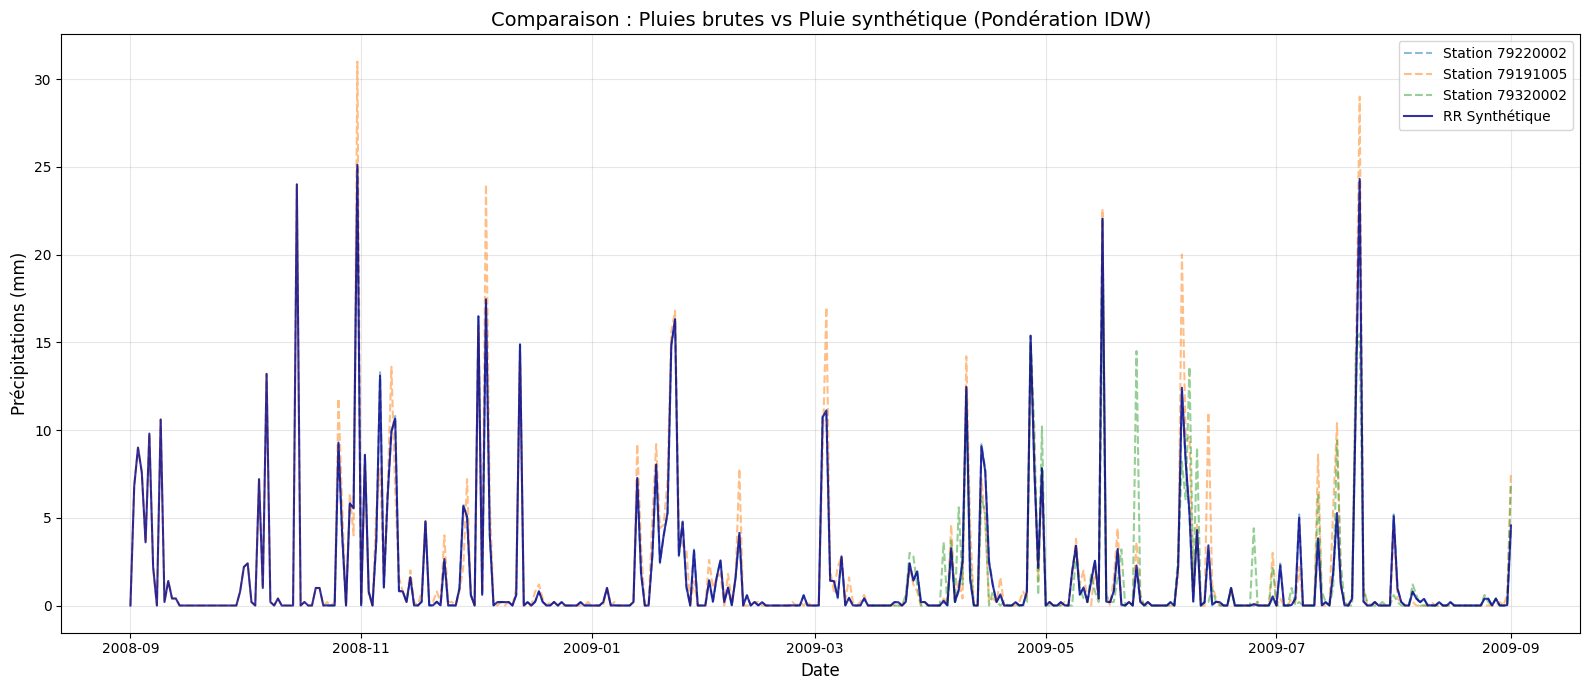

In [ ]:
start_date = '2008-09-01'
end_date = '2009-09-01'
mask = (df_final['date_mesure'] >= start_date) & (df_final['date_mesure'] <= end_date)
df_zoom = df_final.loc[mask]

# 2. Identification des colonnes
cols_rr = [c for c in df_final.columns if ('RR_' in c and c[-1].isnumeric())]
col_synth = 'RR_synth'


plt.figure(figsize=(16, 7))
for col in cols_rr:
    plt.plot(df_zoom['date_mesure'], df_zoom[col], alpha=0.5, linestyle='--', label=f"Station {col.split('_')[1]}")

# Tracé de la synthèse avec une ligne plus épaisse et colorée
plt.plot(df_zoom['date_mesure'], df_zoom[col_synth], alpha = 0.8, color='darkblue', linewidth=1.5, label='RR Synthétique')

plt.title(f"Comparaison : Pluies brutes vs Pluie synthétique (Pondération IDW)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Précipitations (mm)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()


## 2. L'Hydrogramme Pluie-Niveau

En hydrogéologie, l'hydrogramme avec les précipitations inversées en haut (qui "tombent" vers le bas) et le niveau de la nappe en bas. C'est ce qui permet de voir "à l'œil nu" si la nappe réagit vite aux épisodes pluvieux.

Créer un graphique à double axe

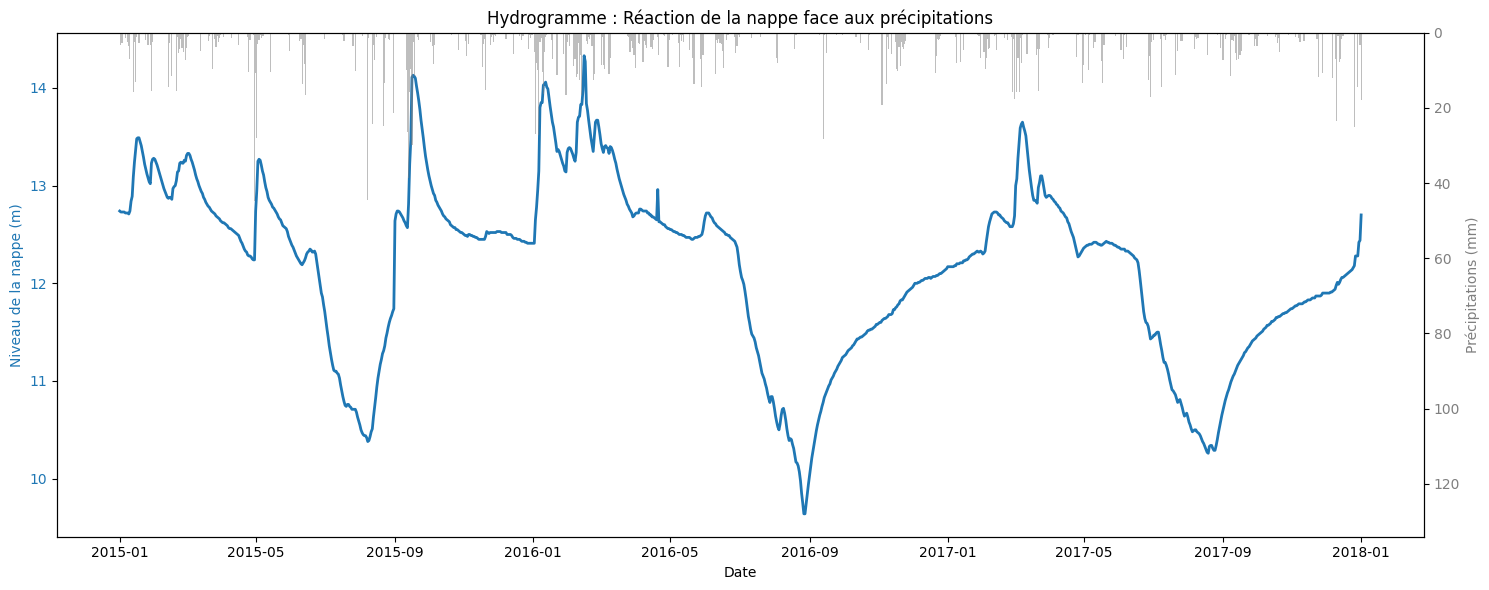

In [ ]:
df_zoom = df_final[(df_final['date_mesure'] >= '2015-01-01') & (df_final['date_mesure'] <= '2018-01-01')]
fig, ax1 = plt.subplots(figsize=(15, 6))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Niveau de la nappe (m)', color=color)
ax1.plot(df_zoom['date_mesure'], df_zoom['niveau_nappe_eau'], color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# La pluie synthétique (en gris/bleu clair, inversé)
ax2 = ax1.twinx()
color = 'tab:gray'
ax2.set_ylabel('Précipitations (mm)', color=color)
ax2.bar(df_zoom['date_mesure'], df_zoom['RR_synth'], color=color, alpha=0.5, width=1)
ax2.tick_params(axis='y', labelcolor=color)

# On inverse l'axe des ordonnées pour la pluie (effet "chute d'eau")
ax2.set_ylim(ax2.get_ylim()[::-1])
ax2.set_ylim(df_zoom['RR_synth'].max() * 3, 0)

plt.title("Hydrogramme : Réaction de la nappe face aux précipitations")
fig.tight_layout()
plt.show()

## 3. La Recherche du "Temps de Réponse" (Cross-Correlation)

L'eau met du temps à s'infiltrer à travers le sol pour atteindre l'aquifère. S'il pleut aujourd'hui, le niveau de la nappe ne montera peut-être que dans 10, 20 ou 40 jours.

Calculer la corrélation croisée (Lags) pour trouver le délai de recharge.

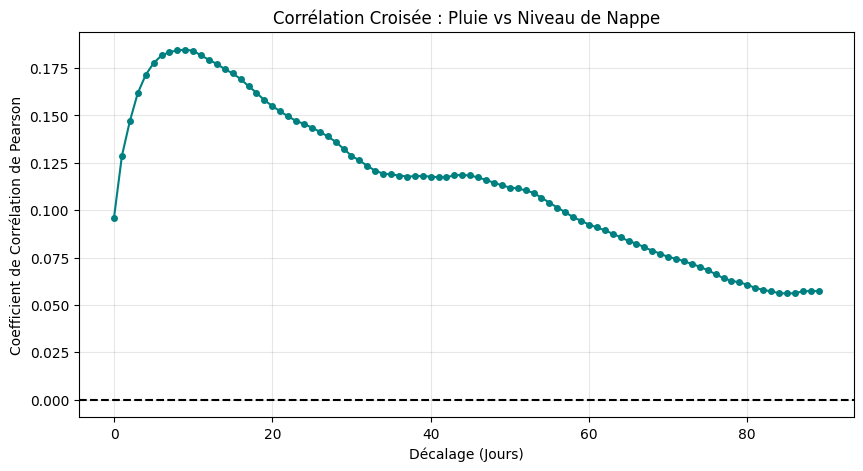

Le temps de réponse optimal estimé de la nappe est de 9 jours.


In [36]:
# On s'assure de ne pas avoir de NaN pour le calcul de corrélation
df_corr = df_final[['RR_synth', 'niveau_nappe_eau']].dropna()

lags = range(0, 90) # On teste des décalages de 0 à 90 jours
corr_values = []

for lag in lags:
    # On décale la pluie vers le futur (ou le niveau vers le passé)
    # Pour voir si la pluie du jour J est corrélée au niveau du jour J+lag
    corr = df_corr['RR_synth'].corr(df_corr['niveau_nappe_eau'].shift(-lag))
    corr_values.append(corr)

plt.figure(figsize=(10, 5))
plt.plot(lags, corr_values, marker='o', color='teal', markersize=4)
plt.axhline(0, color='black', linestyle='--')
plt.title("Corrélation Croisée : Pluie vs Niveau de Nappe")
plt.xlabel("Décalage (Jours)")
plt.ylabel("Coefficient de Corrélation de Pearson")
plt.grid(True, alpha=0.3)
plt.show()

best_lag = lags[np.argmax(np.abs(corr_values))]
print(f"Le temps de réponse optimal estimé de la nappe est de {best_lag} jours.")

## 4. Une petite Heatmap

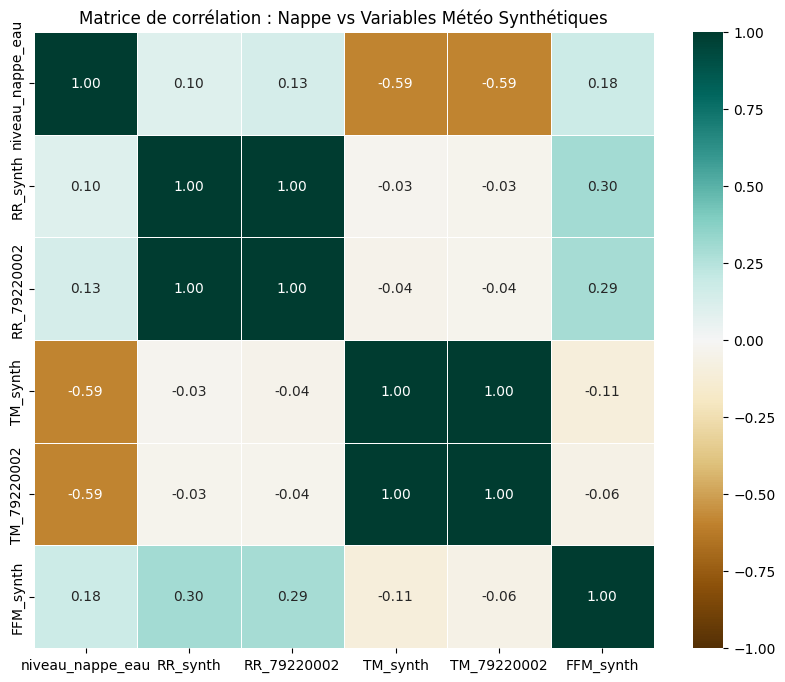

In [39]:
# 1. Calcul de la matrice de corrélation
# On sélectionne uniquement les colonnes numériques pertinentes
cols_to_corr = ['niveau_nappe_eau', 'RR_synth', 'RR_79220002', 'TM_synth', 'TM_79220002','FFM_synth']
corr_mat = df_final[cols_to_corr].corr()

# 2. Configuration de la figure
plt.figure(figsize=(10, 8))

# 3. Création de la Heatmap
sns.heatmap(
    corr_mat,
    vmin=-1,
    vmax=1,
    cmap='BrBG',
    linewidths=.5,
    annot=True,
    annot_kws={"size": 10},
    fmt=".2f" # Pour limiter à 2 décimales et garder la lisibilité
)

plt.title("Matrice de corrélation : Nappe vs Variables Météo Synthétiques")
plt.show()